<a href="https://colab.research.google.com/github/anteodor/Numerical-Methods/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory Work: Numerical Methods

**Student:** Anastasiia Teodorovska  
**Language:** Python (Google Colab)

# 1. Problem Statement

The purpose of this laboratory work is to investigate the application of Newton’s method for solving nonlinear equations and systems of nonlinear equations using numerical techniques implemented in Python.

The first part of the laboratory focuses on the nonlinear function

$$
f(x)=x\sin(4x)
$$

The objective is to analyze the convergence behavior of Newton’s method and investigate how the choice of the initial approximation influences the obtained root and the number of iterations required for convergence. Particular attention is devoted to the dependence of the method on the starting point, since Newton’s method may converge to different roots depending on the selected initial guess.

In addition to the numerical computation of roots, graphical analysis is performed in order to visualize the geometric interpretation of Newton’s method. The laboratory includes the construction of plots illustrating the tangent approximation, the convergence process, the dependence of the obtained roots on the starting approximation, and the variation in iteration counts for different initial points.

The second part of the laboratory is devoted to the numerical solution of a system of nonlinear equations using the multidimensional form of Newton’s method. The following system is considered:

$$
\begin{cases}
x^2+y^2+z^2=2 \\
-x^2+y^2=1 \\
x^2=y
\end{cases}
$$

For this system, the vector form of the equations and the corresponding Jacobian matrix are derived analytically. The numerical solution is then obtained iteratively using matrix-based computations implemented in Python.

The laboratory work is performed in the Google Colab environment using Python together with the NumPy and Matplotlib libraries for numerical calculations and graphical visualization.

# 2. Mathematical Background

Newton’s method is one of the most important iterative numerical techniques used for solving nonlinear equations. The method is based on the local linear approximation of a function using its tangent line.

For a nonlinear equation of the form

$$
f(x)=0
$$

Newton’s iterative formula is defined as

$$
x_{n+1}=x_n-\frac{f(x_n)}{f'(x_n)}
$$

where \(x_n\) represents the current approximation and \(x_{n+1}\) denotes the next approximation of the root.

Geometrically, Newton’s method constructs the tangent line to the function at the current approximation point and computes the intersection of this tangent with the \(x\)-axis. Repeating this process iteratively generates increasingly accurate approximations of the solution.

The convergence properties of Newton’s method strongly depend on the choice of the initial approximation and the behavior of the derivative near the root. If the starting point is sufficiently close to the exact solution and the derivative does not vanish, the method usually demonstrates quadratic convergence, which means that the approximation error decreases very rapidly.

However, inappropriate starting points may lead to slow convergence, convergence to another root, or divergence of the method. In particular, numerical instability may occur near points where the derivative approaches zero.

For systems of nonlinear equations, Newton’s method is generalized using vector and matrix notation. A nonlinear system can be represented in the form

$$
F(X)=0
$$

where

$$
X=
\begin{bmatrix}
x \\
y \\
z
\end{bmatrix}
$$

The multidimensional Newton iteration is defined as

$$
X_{n+1}=X_n-J^{-1}(X_n)F(X_n)
$$

where \(F(X_n)\) is the vector of nonlinear functions and \(J(X_n)\) is the Jacobian matrix containing the partial derivatives of the system.

For the considered system, the Jacobian matrix is given by

$$
J(X)=
\begin{bmatrix}
2x & 2y & 2z \\
-2x & 2y & 0 \\
2x & -1 & 0
\end{bmatrix}
$$

Instead of explicitly computing the inverse matrix, the numerical implementation solves the corresponding linear system

$$
J(X_n)\Delta X=-F(X_n)
$$

where \(\Delta X\) is the correction vector computed at each iteration. The approximation is then updated according to

$$
X_{n+1}=X_n+\Delta X
$$

The iterative process continues until the Euclidean norm of the correction vector becomes smaller than a predefined tolerance value.

# 3. Program Implementation

The laboratory work was implemented in Python using the Google Colab environment. The implementation combines numerical computation techniques with graphical visualization in order to analyze the convergence behavior and stability of Newton’s method.

The NumPy library was used for vector and matrix operations, while Matplotlib was applied for graphical representation of functions and convergence analysis.

At the beginning of the implementation, the nonlinear function

$$
f(x)=x\sin(4x)
$$

and its analytical derivative

$$
f'(x)=\sin(4x)+4x\cos(4x)
$$

were defined. The derivative is required for constructing Newton’s iterative formula and evaluating tangent approximations during the iterative process.

A reusable implementation of Newton’s method for one-dimensional nonlinear equations was then developed. The algorithm iteratively computes new approximations of the root until the stopping criterion is satisfied or the maximum number of iterations is reached.

The implementation additionally includes convergence verification, derivative stability checking, residual error computation, and iterative history storage. Numerical tolerance and iteration limits are configurable parameters of the algorithm.

To investigate the influence of the starting approximation, the method was executed for a large interval of initial guesses. For every starting point, the obtained root and the corresponding number of iterations were stored and analyzed. The collected numerical results were visualized using scatter plots in order to clearly demonstrate the dependence of convergence on the initial approximation.

The graphical analysis includes visualization of the nonlinear function, tangent approximation, initial approximation point, and the computed root. Additional plots illustrate the relationship between the starting approximation and the root obtained by the method, as well as the number of iterations required for convergence.

In the second part of the implementation, Newton’s method was generalized for solving systems of nonlinear equations. The nonlinear system was represented in vector form, and the Jacobian matrix was implemented analytically using partial derivatives of the system equations.

A multidimensional Newton solver based on matrix computations was developed. Instead of explicitly computing the inverse Jacobian matrix, the implementation uses the `numpy.linalg.solve()` function to solve the corresponding linear system directly. This approach improves numerical stability, reduces computational errors, and provides better numerical efficiency.

The implementation also includes handling of singular Jacobian matrices, convergence monitoring using vector norms, residual error evaluation, and iterative solution tracking.

Finally, the obtained numerical solutions were verified by substituting the computed values back into the original equations and evaluating the residual errors of the system.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [ ]:
@dataclass
class NewtonResult:
    root: np.ndarray | float
    iterations: int
    converged: bool
    residual_norm: float
    history: list

In [ ]:
def f(x):
    return x * np.sin(4 * x)


def df(x):
    return np.sin(4 * x) + 4 * x * np.cos(4 * x)

In [ ]:
def newton_1d(f, df, x0, tol=1e-8, max_iter=100, derivative_tol=1e-12):
    x = float(x0)
    history = [x]

    for k in range(1, max_iter + 1):
        derivative = df(x)

        if abs(derivative) < derivative_tol:
            return NewtonResult(x, k - 1, False, abs(f(x)), history)

        x_new = x - f(x) / derivative
        history.append(x_new)

        if abs(x_new - x) < tol:
            return NewtonResult(x_new, k, True, abs(f(x_new)), history)

        x = x_new

    return NewtonResult(x, max_iter, False, abs(f(x)), history)

In [ ]:
x0 = 0.5
result_1d = newton_1d(f, df, x0)

print("Starting point:", x0)
print("Root found:", result_1d.root)
print("Iterations:", result_1d.iterations)
print("Converged:", result_1d.converged)
print("Residual |f(root)|:", result_1d.residual_norm)

Starting point: 0.5
Root found: -5.497787143782138
Iterations: 5
Converged: True
Residual |f(root)|: 4.712993199618385e-15


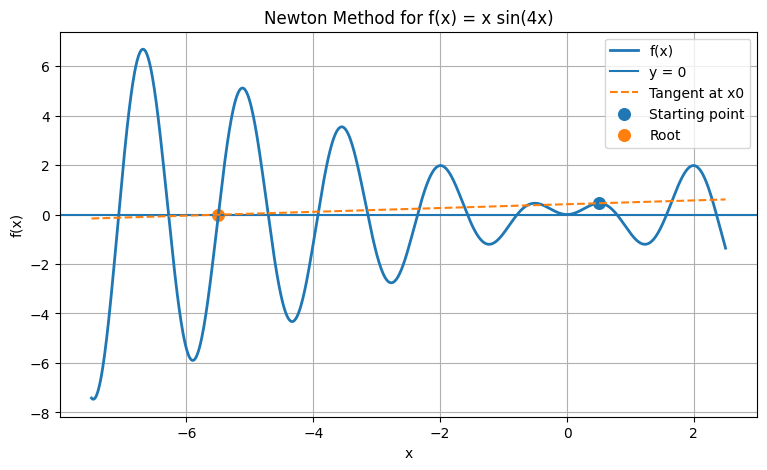

In [ ]:
x_root = result_1d.root
t = np.linspace(min(x0, x_root) - 2, max(x0, x_root) + 2, 1000)

plt.figure(figsize=(9, 5))
plt.plot(t, f(t), linewidth=2, label="f(x)")
plt.axhline(0, linewidth=1.5, label="y = 0")

# Tangent line at the initial point
tangent = df(x0) * (t - x0) + f(x0)
plt.plot(t, tangent, "--", linewidth=1.5, label="Tangent at x0")

plt.scatter([x0], [f(x0)], s=70, label="Starting point")
plt.scatter([x_root], [f(x_root)], s=70, label="Root")

plt.title("Newton Method for f(x) = x sin(4x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
starting_points = np.linspace(-2, 6, 400)

roots = []
iterations = []
convergence_flags = []

for point in starting_points:
    result = newton_1d(f, df, point)
    roots.append(result.root)
    iterations.append(result.iterations)
    convergence_flags.append(result.converged)

roots = np.array(roots)
iterations = np.array(iterations)
convergence_flags = np.array(convergence_flags)

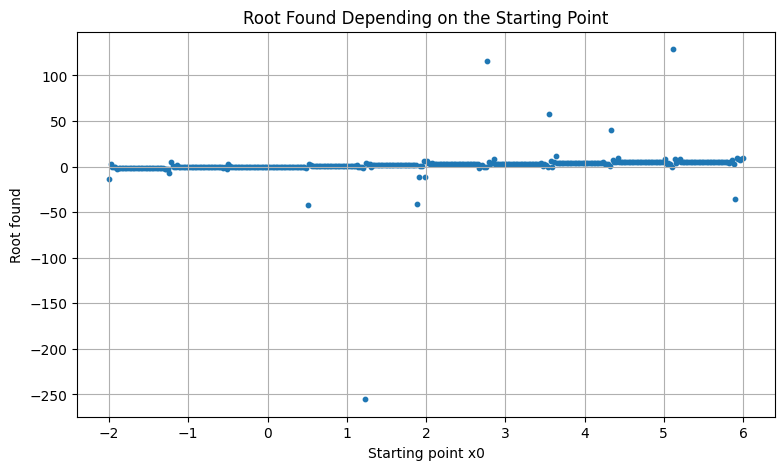

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(starting_points, roots, s=10)
plt.title("Root Found Depending on the Starting Point")
plt.xlabel("Starting point x0")
plt.ylabel("Root found")
plt.grid(True)
plt.show()

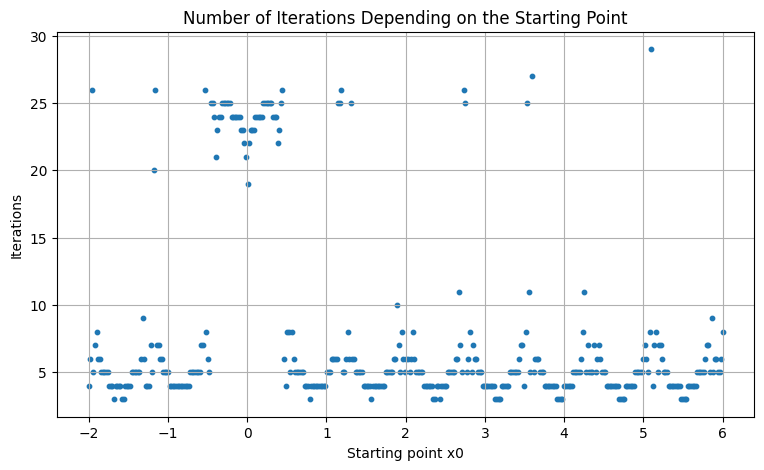

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(starting_points, iterations, s=10)
plt.title("Number of Iterations Depending on the Starting Point")
plt.xlabel("Starting point x0")
plt.ylabel("Iterations")
plt.grid(True)
plt.show()

In [ ]:
def newton_system(F, J, x0, tol=1e-8, max_iter=50):
    x = np.array(x0, dtype=float)
    history = [x.copy()]

    for k in range(1, max_iter + 1):
        F_value = np.array(F(x), dtype=float)
        J_value = np.array(J(x), dtype=float)

        try:
            delta = np.linalg.solve(J_value, -F_value)
        except np.linalg.LinAlgError:
            return NewtonResult(x, k - 1, False, np.linalg.norm(F_value), history)

        x = x + delta
        history.append(x.copy())

        if np.linalg.norm(delta) < tol:
            return NewtonResult(x, k, True, np.linalg.norm(F(x)), history)

    return NewtonResult(x, max_iter, False, np.linalg.norm(F(x)), history)

In [ ]:
def F_example(xy):
    x, y = xy
    return [
        x + 2 * y - 2,
        x**2 + 4 * y**2 - 4
    ]


def J_example(xy):
    x, y = xy
    return [
        [1, 2],
        [2 * x, 8 * y]
    ]

In [ ]:
result_example = newton_system(F_example, J_example, x0=[1.0, 2.0])

print("Solution:", result_example.root)
print("Iterations:", result_example.iterations)
print("Converged:", result_example.converged)
print("Residual norm:", result_example.residual_norm)
print("F(solution):", F_example(result_example.root))

Solution: [1.50295992e-16 1.00000000e+00]
Iterations: 6
Converged: True
Residual norm: 0.0
F(solution): [np.float64(0.0), np.float64(0.0)]


In [ ]:
def F_exercise(xyz):
    x, y, z = xyz
    return [
        x + y + z - 3,
        x**2 + y**2 + z**2 - 5,
        np.exp(x) + x * y - x * z - 1
    ]


def J_exercise(xyz):
    x, y, z = xyz
    return [
        [1, 1, 1],
        [2 * x, 2 * y, 2 * z],
        [np.exp(x) + y - z, x, -x]
    ]

In [ ]:
result_exercise = newton_system(F_exercise, J_exercise, x0=[2.0, 1.0, 2.0])

print("Solution:", result_exercise.root)
print("Iterations:", result_exercise.iterations)
print("Converged:", result_exercise.converged)
print("Residual norm:", result_exercise.residual_norm)
print("F(solution):", F_exercise(result_exercise.root))

Solution: [ 1.22439432 -0.09313314  1.86873882]
Iterations: 7
Converged: True
Residual norm: 4.440892098500626e-16
F(solution): [np.float64(0.0), np.float64(0.0), np.float64(-4.440892098500626e-16)]


In [ ]:
def F_slow(xy):
    x, y = xy
    return [
        x**2 + y**2 - 1e-13,
        x + y
    ]


def J_slow(xy):
    x, y = xy
    return [
        [2 * x, 2 * y],
        [1, 1]
    ]

In [ ]:
result_slow = newton_system(F_slow, J_slow, x0=[2.0, 1.0])

print("Solution:", result_slow.root)
print("Iterations:", result_slow.iterations)
print("Converged:", result_slow.converged)
print("Residual norm:", result_slow.residual_norm)
print("F(solution):", F_slow(result_slow.root))

Solution: [ 2.23609532e-07 -2.23609532e-07]
Iterations: 27
Converged: True
Residual norm: 2.445949795669061e-18
F(solution): [np.float64(2.445949795669061e-18), np.float64(0.0)]


In [ ]:
def F_lab(xyz):
    x, y, z = xyz
    return [
        x**2 + y**2 + z**2 - 2,
        -x**2 + y**2 - 1,
        x**2 - y
    ]


def J_lab(xyz):
    x, y, z = xyz
    return [
        [2*x, 2*y, 2*z],
        [-2*x, 2*y, 0],
        [2*x, -1, 0]
    ]

In [ ]:
result_lab = newton_system(F_lab, J_lab, x0=[1.0, 1.0, 1.0])

print("Solution:", result_lab.root)
print("Iterations:", result_lab.iterations)
print("Converged:", result_lab.converged)
print("Residual norm:", result_lab.residual_norm)
print("F(solution):", F_lab(result_lab.root))

Solution: [1.27201965 1.61803399 1.21204132]
Iterations: 50
Converged: False
Residual norm: 3.705112139737591
F(solution): [np.float64(3.705112139737591), np.float64(-6.661338147750939e-16), np.float64(6.661338147750939e-16)]


# 4. Results and Discussion

In this part of the laboratory work, the implemented Newton methods were tested on both a single nonlinear equation and several systems of nonlinear equations. The obtained numerical results demonstrate not only the efficiency of Newton’s method, but also its sensitivity to the initial approximation and to the structure of the equations being solved.

For the function

$$
f(x)=x\sin(4x),
$$

Newton’s method was started from the initial approximation

$$
x_0=0.5.
$$

The method converged successfully after 5 iterations and produced the root

$$
x \approx -5.4977871438.
$$

The residual value was

$$
|f(x)| \approx 4.71\cdot 10^{-15},
$$

which is extremely close to zero. This confirms that the obtained value is a valid numerical root of the equation within the selected tolerance. Although the initial point was positive, the method converged to a negative root. This result clearly illustrates an important property of Newton’s method: the final root depends strongly on the starting point and on the local behavior of the tangent lines during the iteration process.

The graphical representation of the function and the tangent line confirms the geometric interpretation of Newton’s method. At each step, the method uses the tangent to the curve at the current approximation and finds its intersection with the \(x\)-axis. The plotted result shows that the tangent constructed at the initial point leads the iteration process toward one of the available roots of the oscillating function.

The plot showing the dependence of the obtained root on the starting point demonstrates that Newton’s method does not always converge to the nearest visible root. Since the function

$$
f(x)=x\sin(4x)
$$

has many roots, different initial approximations may lead to different final solutions. Most starting points converge to roots located near the main oscillatory structure of the function, but some points lead to significantly distant roots. These outliers appear because the tangent line may intersect the \(x\)-axis far away from the current approximation, especially when the derivative is small or when the function changes rapidly.

The second plot, which shows the number of iterations depending on the starting point, also confirms the sensitivity of Newton’s method. For many initial points, convergence was achieved in approximately 3 to 8 iterations. However, several starting points required more than 20 iterations. This behavior occurs when the initial approximation is located in a region where the derivative is close to zero or where the tangent direction is not favorable for fast convergence. Therefore, the number of iterations is not constant and depends directly on the selected starting value.

The method was also tested on the example system

$$
\begin{cases}
x+2y-2=0,\\
x^2+4y^2-4=0.
\end{cases}
$$

For this system, Newton’s method converged successfully after 6 iterations and produced the solution

$$
x \approx 0,\qquad y \approx 1.
$$

The residual norm was equal to zero, which means that the computed solution satisfies both equations with high numerical accuracy.

For the additional nonlinear system from the provided code example, Newton’s method converged after 7 iterations and produced the solution

$$
x \approx 1.22439432,\qquad
y \approx -0.09313314,\qquad
z \approx 1.86873882.
$$

The residual norm was approximately

$$
4.44\cdot 10^{-16},
$$

which is practically zero. This confirms that the multidimensional Newton method was implemented correctly and can effectively solve nonlinear systems when the system has a suitable real solution and the initial approximation is chosen appropriately.

The slow convergence example produced the solution

$$
x \approx 2.23609532\cdot 10^{-7},\qquad
y \approx -2.23609532\cdot 10^{-7}.
$$

The method converged after 27 iterations, which is significantly slower than in the previous examples. The residual norm was approximately

$$
2.45\cdot 10^{-18}.
$$

This example demonstrates that Newton’s method may converge slowly when the system is close to a degenerate case or when the Jacobian matrix leads to very small correction steps. Even though the final residual is very small, the number of iterations is much larger than in the regular examples.

For the laboratory system

$$
\begin{cases}
x^2+y^2+z^2=2,\\
-x^2+y^2=1,\\
x^2=y,
\end{cases}
$$

the method returned the approximation

$$
x \approx 1.27201965,\qquad
y \approx 1.61803399,\qquad
z \approx 1.21204132.
$$

However, the method did not satisfy the convergence criterion within the maximum number of iterations. The output shows

$$
\text{Converged} = \text{False},
$$

and the residual norm was approximately

$$
3.7051.
$$

This means that the obtained values cannot be considered an accurate solution of the full system. Substitution into the equations shows that the second and third equations are satisfied almost exactly, but the first equation has a large residual. This indicates that the real-valued system is inconsistent.

Indeed, from the third equation we have

$$
y=x^2.
$$

Substituting this into the second equation gives

$$
-x^2+y^2=1.
$$

Since \(x^2=y\), this becomes

$$
-y+y^2=1,
$$

or

$$
y^2-y-1=0.
$$

The positive solution is

$$
y=\frac{1+\sqrt{5}}{2}\approx 1.618.
$$

Then

$$
x^2=y\approx 1.618.
$$

Substituting these values into the first equation gives

$$
x^2+y^2+z^2=2.
$$

Since

$$
x^2\approx 1.618
$$

and

$$
y^2\approx 2.618,
$$

we obtain

$$
1.618+2.618+z^2=2.
$$

Therefore,

$$
z^2\approx -2.236,
$$

which has no real solution. As a result, the system does not have a real-valued solution, and Newton’s method cannot converge to a valid real root. This explains why the residual norm remains large even after 50 iterations.

Overall, the results confirm that Newton’s method is a powerful and efficient numerical method when applied to well-posed nonlinear equations and systems with appropriate initial approximations. At the same time, the experiments clearly show that the method is sensitive to the starting point, may converge to different roots, may require many iterations in difficult cases, and may fail to converge when the system has no real solution or when the Jacobian structure is unfavorable.

# 5. Conclusions

In this laboratory work, Newton’s method was successfully implemented and analyzed for both single nonlinear equations and systems of nonlinear equations using Python in the Google Colab environment.

The experiments confirmed that Newton’s method is an efficient and powerful iterative numerical technique capable of achieving very high accuracy with a relatively small number of iterations when the initial approximation is chosen appropriately. For most tested problems, the method demonstrated fast convergence and produced residual errors close to machine precision.

The graphical analysis clearly illustrated the geometric interpretation of Newton’s method and demonstrated the strong dependence of convergence behavior on the starting approximation. The obtained plots showed that different initial guesses may lead to different roots and significantly different iteration counts. In several cases, the method required many iterations due to unfavorable starting points or small derivative values.

The implementation of the multidimensional Newton method for systems of nonlinear equations also produced accurate solutions for consistent systems. The use of the Jacobian matrix together with direct linear system solving via `numpy.linalg.solve()` provided stable and efficient numerical computations.

The slow convergence example demonstrated that Newton’s method may become inefficient for nearly degenerate systems or systems producing very small correction steps. Although convergence was eventually achieved, the iteration count increased significantly compared to the regular cases.

The analysis of the laboratory system additionally showed that Newton’s method cannot converge to a valid real-valued solution when the nonlinear system itself is inconsistent in the real domain. The residual analysis and analytical verification confirmed the absence of a real solution for the given system, explaining the failure of convergence.

Overall, the laboratory work provided a detailed practical understanding of Newton’s method, its convergence properties, numerical stability, advantages, and limitations. The experiments demonstrated both the effectiveness of the method for well-posed nonlinear problems and its sensitivity to the choice of initial conditions and the mathematical properties of the system being solved.